**Title: Comparison of various Machine Learning/ Deep Learning model on Deep fake images**

**Motivation and Problem Statement**

Generative AI is progressing rapidly in today’s age. Newer and newer off-the-shelf models are readily available almost every day. One domain which is also impacted by gen ai is image generation. And with accuracy of the models increasing day by day, the images generated are that much more humanlike.

Here is where Deepfake technology comes in. Deepfake simply means images, audio or video which are generated using artificial intelligence. It is a type of synthetic media. Deepfake technology has advanced rapidly, making it increasingly difficult to distinguish real images from manipulated ones.

While deepfake techniques have useful applications, such as in entertainment and education, they also pose serious threats, including misinformation, identity theft, and fraud. This project aims to compare various machine learning and deep learning models in detecting deepfake images, evaluating their effectiveness in identifying manipulated content.

**Dataset**

The project will use publicly available datasets containing deepfake images from Kaggle[1]

**Team 130**

*   Prathamesh Thakur
*   Nayan Taori
*   Harsh More

**Previous Work**

There is no prior work done by the team on this specific project.

**References**

[1] https://www.kaggle.com/datasets/alessandrasala79/ai-vs-human-generated-dataset

#Importing necessary libraries and data

In [ ]:
import kagglehub
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import torch
import torchvision.transforms as transforms

plt.style.use('ggplot')

###Kaggle provides a web api kagglehub which downloads the data in their cloud itself, allowing anyone to work remotely with it without the need to download it on their system.

In [ ]:
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4


###This code is used to extract the training and test sets from the cloud and perform some basic preprocessing.

In [ ]:
paths = []
for dirpath, dirname, filenames in os.walk(path):
  if dirpath == path:
    df_train = pd.read_csv(path + '/' + filenames[1])
    df_test = pd.read_csv(path + '/' + filenames[0])

df_train.drop('Unnamed: 0', axis = 1, inplace = True)
df_train['file_name'] = path + '/' + df_train['file_name']
df_test['id'] = path + '/' + df_test['id']

#Exploratory data analysis

###Basic information about the train and test sets.

In [ ]:
df_train.head()

,file_name,label
0,/root/.cache/kagglehub/datasets/alessandrasala...,1
1,/root/.cache/kagglehub/datasets/alessandrasala...,0
2,/root/.cache/kagglehub/datasets/alessandrasala...,1
3,/root/.cache/kagglehub/datasets/alessandrasala...,0
4,/root/.cache/kagglehub/datasets/alessandrasala...,1


In [ ]:
df_test.head()

,id
0,/root/.cache/kagglehub/datasets/alessandrasala...
1,/root/.cache/kagglehub/datasets/alessandrasala...
2,/root/.cache/kagglehub/datasets/alessandrasala...
3,/root/.cache/kagglehub/datasets/alessandrasala...
4,/root/.cache/kagglehub/datasets/alessandrasala...


In [ ]:
df_train.shape

(79950, 2)

In [ ]:
df_test.shape

(5540, 1)

###The chart below shows the distribution of labels in the dataset. As visible, it is balanced, with equal number of images of both types. A 1 represents an AI generated image whereas 0 represents one not generated by AI.

In [ ]:
df_train['label'].plot(kind = 'hist')
plt.show()

###The code block extracts first 5 AI generated and 5 non ai generated images from the dataset.

In [ ]:
im_h = []
im_ai = []

for index, row in df_train.iterrows():
  if len(im_h) < 6:
    if row['label'] == 0:
      im_h.append(row['file_name'])

  if len(im_ai) < 6:
    if row['label'] == 1:
      im_ai.append(row['file_name'])

  if len(im_h) == 5 and len(im_ai) == 5:
    break

###Example non AI generated images.

In [ ]:
for i in im_h:
  im = Image.open(i)
  display(im)

###Example AI generated images.

In [ ]:
for i in im_ai:
  im = Image.open(i)
  display(im)

###The code block below shows the pixel value distribution for an AI generated image vs a non AI generated image. It is based on the channels of color as well as the overall pixel intensity. This can help us identify of any distinctive patterns within the images.

In [ ]:
temp1 = Image.open(im_h[0])
im_human = np.array(temp1)

temp2 = Image.open(im_ai[0])
im_ai = np.array(temp2)

fig, axs = plt.subplots(4, 2, figsize = (20, 6))
plt.subplots_adjust(hspace = 1)

axs[0][0].hist(im_human[:, :, 0].flatten(), bins=256, range=[0, 256], color='red')
axs[0][0].set_title("Pixel Value Histogram (Red Channel) for human image")
axs[0][1].hist(im_ai[:, :, 0].flatten(), bins=256, range=[0, 256], color='red')
axs[0][1].set_title("Pixel Value Histogram (Red Channel) for AI generated image")

axs[1][0].hist(im_human[:, :, 1].flatten(), bins=256, range=[0, 256], color='green')
axs[1][0].set_title("Pixel Value Histogram (Green Channel) for human image")
axs[1][1].hist(im_ai[:, :, 1].flatten(), bins=256, range=[0, 256], color='green')
axs[1][1].set_title("Pixel Value Histogram (Green Channel) for AI generated image")

axs[2][0].hist(im_human[:, :, 2].flatten(), bins=256, range=[0, 256], color='blue')
axs[2][0].set_title("Pixel Value Histogram (Blue Channel) for human image")
axs[2][1].hist(im_ai[:, :, 2].flatten(), bins=256, range=[0, 256], color='blue')
axs[2][1].set_title("Pixel Value Histogram (Blue Channel) for AI generated image")

axs[3][0].hist(im_human.flatten(), bins=256, range=[0, 256], color='gray')
axs[3][0].set_title("Pixel Value Histogram (All Channels) for human image")
axs[3][1].hist(im_ai.flatten(), bins=256, range=[0, 256], color='gray')
axs[3][1].set_title("Pixel Value Histogram (All Channels) for AI generated image")

plt.show()

###The below code block is used to convert the image into numeric format (tensors) to make it easier for analysis.

In [ ]:
color_channels = []
heights = []
widths = []
brightness = []

tensorize = transforms.ToTensor()

for i in range(len(df_train)):
  url = df_train['file_name'].iloc[i]
  im = tensorize(Image.open(url))
  color_channels.append(im.shape[0])
  widths.append(im.shape[1])
  heights.append(im.shape[2])
  im1 = tensorize(Image.open(url).convert('L'))
  brightness.append(torch.mean(im1).item())

color_channels = pd.Series(color_channels)
heights = pd.Series(heights)
widths = pd.Series(widths)
brightness = pd.Series(brightness)

aspect_ratios = pd.Series(widths / heights)

###The number of color channels denote whether the image is grayscale(1) or colored(3).

In [ ]:
color_channels.value_counts()

###This function streamlines the task of plotting a graph.

In [ ]:
def plot_graph(data, string):
  plt.hist(data, density = True, alpha = 0.6, color = 'teal')
  sns.kdeplot(data, color='navy')
  plt.title('Image ' + string + ' frequency distribution')
  plt.xlabel(string + ' of image')
  plt.ylabel('Frequency')
  plt.show()

###Shows how the image widths are distributed among the data.

In [ ]:
plot_graph(widths, 'Width')

###Shows how the image heights are distributed among the data.

In [ ]:
plot_graph(heights, 'Height')

###Shows how the aspect ratio (ratio of height to width) is distributed among the data.

In [ ]:
plot_graph(aspect_ratios, 'Aspect Ratio')

###Shows the distribution of brightness (overall pixel intensities) among the data.

In [ ]:
plot_graph(brightness, 'Brightness')

In [ ]:
from tensorflow.keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from sklearn.model_selection import train_test_split

IMG_SIZE = (128, 128)  # Resize images
BATCH_SIZE = 32

# Function to load and preprocess images
def load_and_preprocess_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)  # Resize
    img_array = img_to_array(img) / 255.0  # Normalize
    return img_array

# Load all images and labels
image_data = []
labels = []

for row in df_train['file_name'][:500]:
  image_data.append(load_and_preprocess_image(row))

# Convert to numpy arrays
image_data = np.array(image_data)
labels = df_train['label'][:500]

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(image_data, labels, test_size=0.2, random_state=1234)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

Train shape: (400, 128, 128, 3), Validation shape: (100, 128, 128, 3)


In [ ]:
X_train

array([[[[0.93333334, 0.8980392 , 0.7764706 ],
         [0.9411765 , 0.9019608 , 0.79607844],
         [0.9411765 , 0.9019608 , 0.8039216 ],
         ...,
         [0.96862745, 0.9490196 , 0.8745098 ],
         [0.96862745, 0.9490196 , 0.8745098 ],
         [0.96862745, 0.9490196 , 0.8745098 ]],

        [[0.94509804, 0.9098039 , 0.78039217],
         [0.9490196 , 0.9137255 , 0.7921569 ],
         [0.9490196 , 0.9137255 , 0.8       ],
         ...,
         [0.9764706 , 0.92941177, 0.827451  ],
         [0.9764706 , 0.92941177, 0.827451  ],
         [0.9764706 , 0.92941177, 0.827451  ]],

        [[0.9372549 , 0.8784314 , 0.7176471 ],
         [0.9372549 , 0.8784314 , 0.7254902 ],
         [0.94509804, 0.88235295, 0.7490196 ],
         ...,
         [0.972549  , 0.91764706, 0.7647059 ],
         [0.972549  , 0.91764706, 0.7647059 ],
         [0.972549  , 0.91764706, 0.7647059 ]],

        ...,

        [[0.98039216, 0.8784314 , 0.64705884],
         [0.99607843, 0.8627451 , 0.52156866]

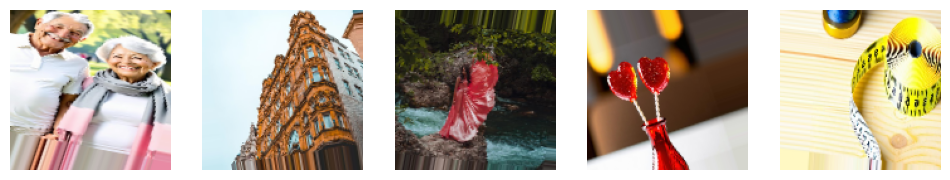

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Define augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Generate augmented images
augmented_images = datagen.flow(X_train[:5], batch_size=5)

# Display augmented images
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, img in enumerate(augmented_images):  # Only one batch of 5 images
    if i >= 1:  # Only process the first batch
        break
    for j in range(5):  # Loop through the 5 images in the batch
        axes[j].imshow(img[j])  # img[j] is the individual image in the batch
        axes[j].axis("off")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(2, activation="softmax")  # Number of categories
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
                    validation_data=(X_val, y_val),
                    epochs=5,
                    verbose=1)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5120 - loss: 0.9484 - val_accuracy: 0.5200 - val_loss: 0.6280
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6197 - loss: 0.6096 - val_accuracy: 0.6500 - val_loss: 0.5841
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7757 - loss: 0.5357 - val_accuracy: 0.7100 - val_loss: 0.6354
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8002 - loss: 0.5013 - val_accuracy: 0.7700 - val_loss: 0.5434
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8014 - loss: 0.5256 - val_accuracy: 0.7500 - val_loss: 0.6196


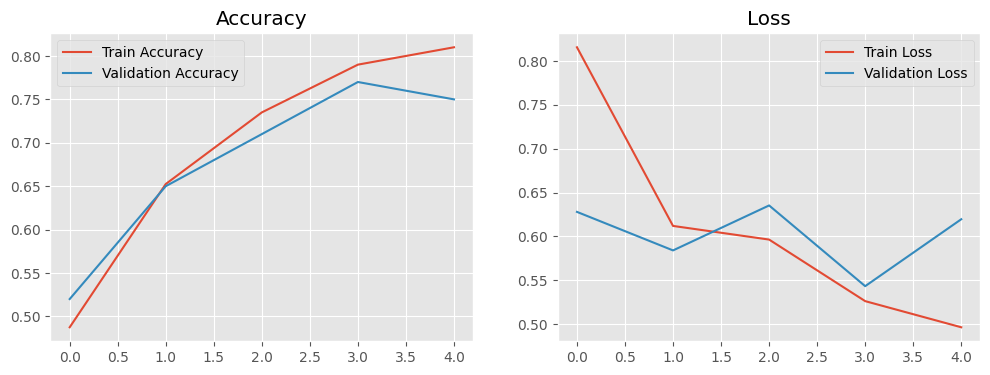

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()